In [32]:
!pip install dagshub mlflow

In [33]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
PATH = '/kaggle/input/competitions/house-prices-advanced-regression-techniques/'
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


# Dagshub/MLflow Initialization

In [34]:
import dagshub
import mlflow

dagshub.init(repo_owner='ZukaCS', 
             repo_name='house-prices-ML-assignment1', 
             mlflow=True)

Initialized MLflow to track repo "ZukaCS/house-prices-ML-assignment1"

Repository ZukaCS/house-prices-ML-assignment1 initialized!

# EDA

In [35]:
df = pd.read_csv(PATH + 'train.csv')

In [54]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [36]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [55]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (1168, 80)
Test shape: (292, 80)


In [56]:
X_train.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
Alley             object
LotShape          object
LandContour       object
Utilities         object
LotConfig         object
LandSlope         object
Neighborhood      object
Condition1        object
Condition2        object
BldgType          object
HouseStyle        object
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
RoofStyle         object
RoofMatl          object
Exterior1st       object
Exterior2nd       object
MasVnrType        object
MasVnrArea       float64
ExterQual         object
ExterCond         object
Foundation        object
BsmtQual          object
BsmtCond          object
BsmtExposure      object
BsmtFinType1      object
BsmtFinSF1         int64
BsmtFinType2      object
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
Heating           object


In [64]:
X_train.describe()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1168.000000,1168.000000,951.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1162.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1104.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000
mean,730.904966,56.849315,70.343849,10689.642123,6.121575,5.584760,1970.965753,1984.897260,103.771945,446.023973,45.152397,570.595034,1061.771404,1169.354452,352.351027,5.696062,1527.401541,0.425514,0.057363,1.577055,0.381849,2.890411,1.047945,6.561644,0.618151,1978.662138,1.781678,476.273973,95.946918,49.578767,21.839041,3.812500,15.407534,2.955479,51.267123,6.356164,2007.818493
std,425.369088,42.531862,24.897021,10759.366198,1.367619,1.116062,30.675495,20.733955,173.032238,459.070977,158.217499,446.364551,440.676330,386.675268,439.570872,47.887106,524.432686,0.519969,0.236289,0.546912,0.499953,0.804855,0.225448,1.619706,0.645129,24.728938,0.740161,211.095373,129.685939,69.433580,62.083227,31.519664,55.881148,41.648504,553.039684,2.670707,1.322639
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,360.750000,20.000000,59.000000,7587.250000,5.000000,5.000000,1953.000000,1966.000000,0.000000,0.000000,0.000000,222.500000,796.000000,888.000000,0.000000,0.000000,1145.750000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.750000,1.000000,341.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000
50%,732.500000,50.000000,70.000000,9600.000000,6.000000,5.000000,1972.000000,1994.000000,0.000000,384.500000,0.000000,480.000000,997.500000,1095.000000,0.000000,0.000000,1473.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,482.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,1101.750000,70.000000,80.000000,11700.000000,7.000000,6.000000,2001.000000,2004.000000,166.000000,721.000000,0.000000,810.250000,1299.250000,1396.750000,728.000000,0.000000,1792.000000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,74.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1378.000000,5644.000000,1127.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000


In [57]:
print(X_train.isnull().sum())

Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       217
LotArea             0
Street              0
Alley            1094
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        683
MasVnrArea          6
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           28
BsmtCond           28
BsmtExposure       28
BsmtFinType1       28
BsmtFinSF1          0
BsmtFinType2       28
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

In [40]:
missing_num = sum(X_train.isna().sum() > 0)
print(f'columns with NAN-s count: {missing_num}')

columns with NAN-s count: 19


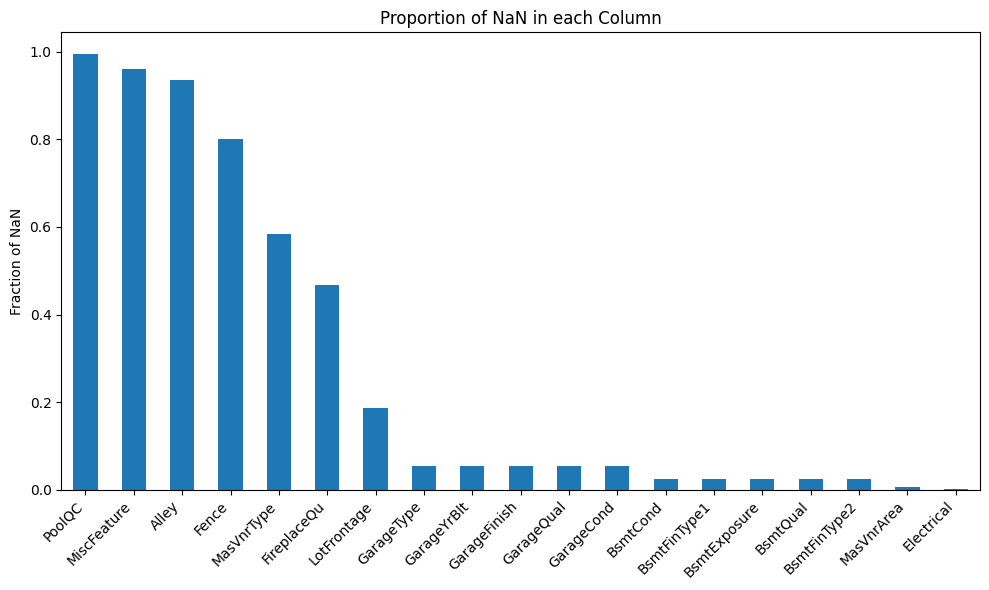

In [41]:
import matplotlib.pyplot as plt

null_ratio = X_train.isna().sum() / X_train.shape[0]
null_ratio = null_ratio[null_ratio > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
null_ratio.plot(kind='bar')
plt.title('Proportion of NaN in each Column')
plt.ylabel('Fraction of NaN')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [58]:
cat_cols = [col for col in X_train.columns if X_train[col].dtype== 'object']
num_cols = [col for col in X_train.columns if X_train[col].dtype != 'object']

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numerical columns ({len(num_cols)}): {num_cols}")



Categorical columns (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Numerical columns (37): ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageC

<Figure size 1500x1000 with 0 Axes>

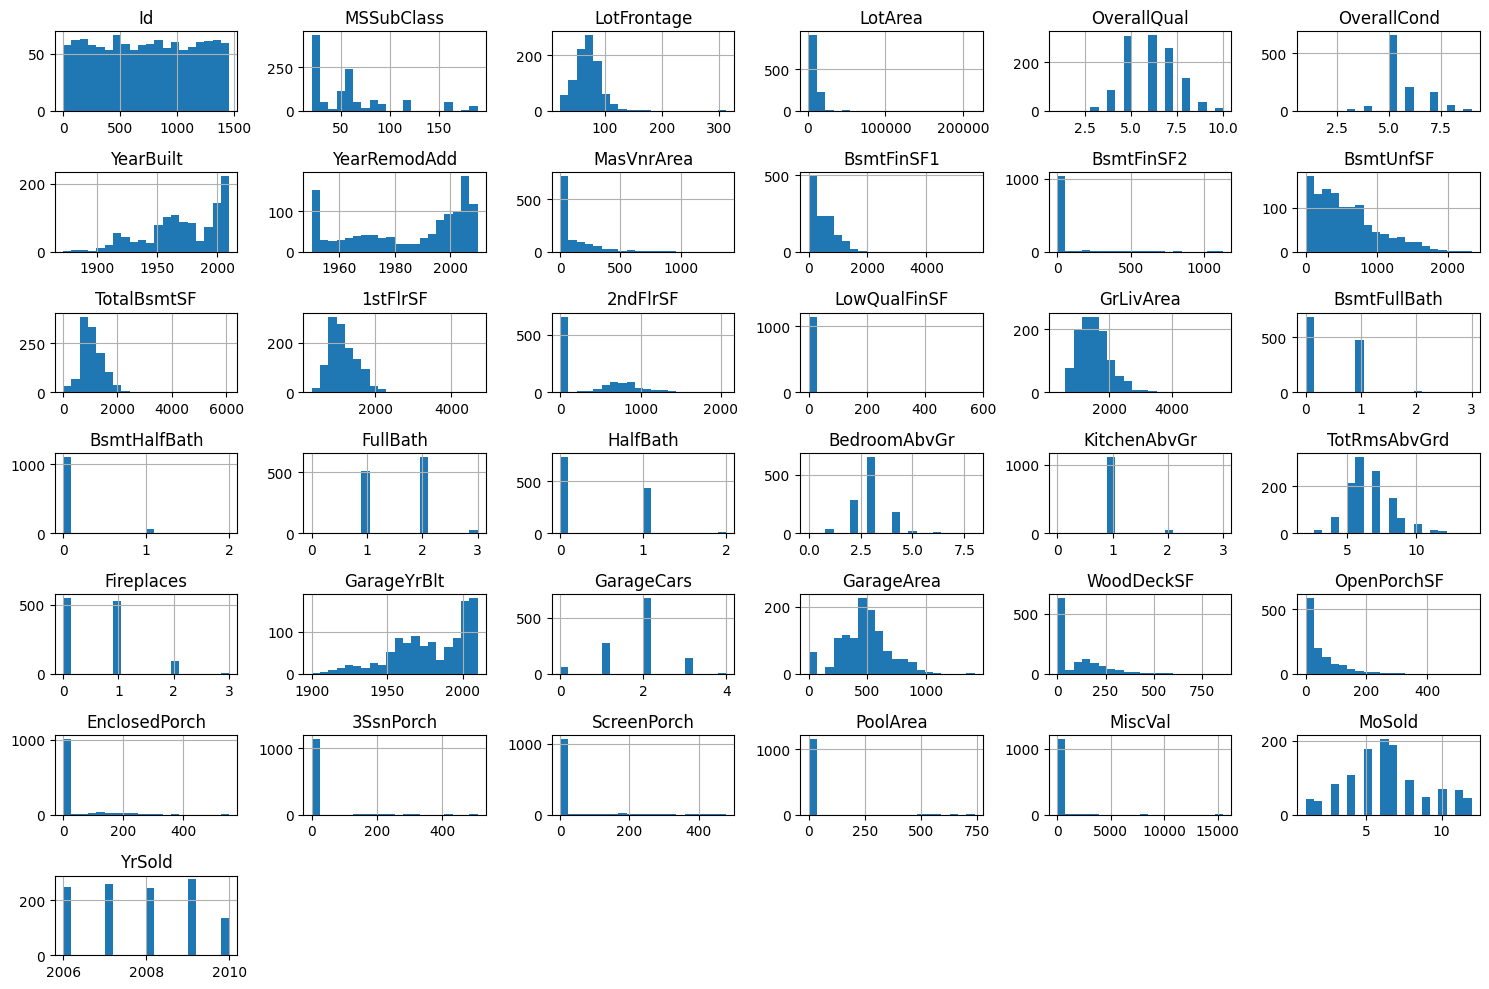

In [43]:
import matplotlib.pyplot as plt

X_train[num_cols].describe()

plt.figure(figsize=(15, 10))
X_train[num_cols].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

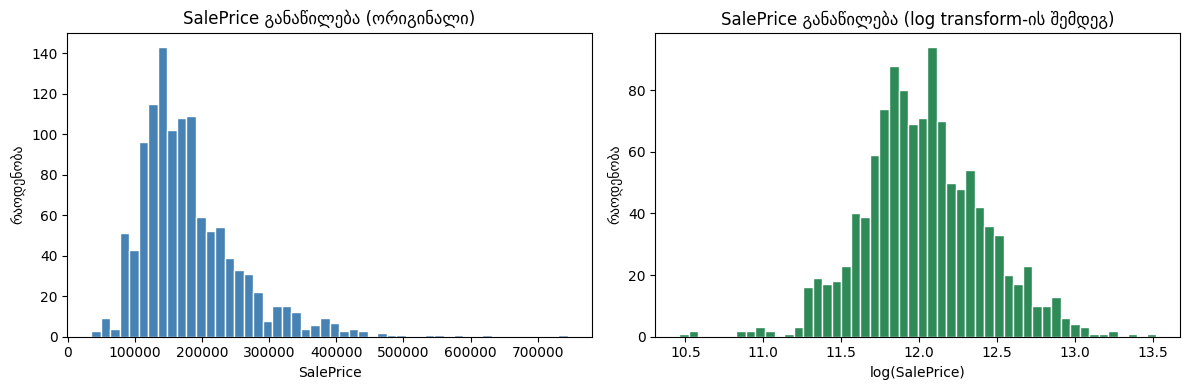

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice განაწილება (ორიგინალი)')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('რაოდენობა')
axes[1].hist(np.log1p(y_train), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('SalePrice განაწილება (log transform-ის შემდეგ)')
axes[1].set_xlabel('log(SalePrice)')
axes[1].set_ylabel('რაოდენობა')

plt.tight_layout()
plt.savefig('sale_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Cleaning / Data preprocessing

In [44]:
from sklearn.base import BaseEstimator, TransformerMixin

class HouseHandleNaN(BaseEstimator, TransformerMixin):
    cat_na_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                   'BsmtCond', 'BsmtFinType1', 'BsmtExposure', 'BsmtQual', 'BsmtFinType2',
                   'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'MasVnrType']
    num_na_cols = ['GarageYrBlt']
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        for col in self.cat_na_cols:
            if col in X.columns:
                X[col] = X[col].fillna("None")
        for col in self.num_na_cols:
            if col in X.columns:
                X[col] = X[col].fillna(0)
        return X

# Feature engineering 

In [45]:
class HouseFeatureAdderAndModifier(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        
        # make total areas
        X["TotalSF"]  = X["TotalBsmtSF"] + X["1stFlrSF"] + X["2ndFlrSF"]
        X["TotalPorchSF"] = X["OpenPorchSF"] + X["EnclosedPorch"] + X["3SsnPorch"] + X["ScreenPorch"]

        X["TotalBath"] = X["FullBath"] + X["BsmtFullBath"] + 0.4*X["HalfBath"] + 0.4*X["BsmtHalfBath"] #maybe people like Full baths more and less halfs
        X["HouseAge"]   = X["YrSold"] - X["YearBuilt"]
        X["RemodelAge"] = X["YrSold"] - X["YearRemodAdd"]
        
        X["BsmtFinTotal"] = X["BsmtFinSF1"] + X["BsmtFinSF2"]
     
        X["HasGarage"]    = (X["GarageArea"] > 0).astype(int)
        X["HasBasement"]  = (X["TotalBsmtSF"] > 0).astype(int)
        X["HasPool"]      = (X["PoolArea"] > 0).astype(int)
        X["Has2ndFloor"]  = (X["2ndFlrSF"] > 0).astype(int)
        X["WasRemodeled"] = (X["YearRemodAdd"] != X["YearBuilt"]).astype(int)
        
        # drop things we used to make other columns
        X = X.drop(columns=[
            "1stFlrSF", "2ndFlrSF",          
            "OpenPorchSF", "EnclosedPorch",   
            "3SsnPorch", "ScreenPorch",       
            "FullBath", "HalfBath",           
            "BsmtFullBath", "BsmtHalfBath",   
            "BsmtFinSF1", "BsmtFinSF2",     
            "YearBuilt", "YearRemodAdd",      
        ])
        
        return X

In [46]:
class OrdinalEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        
        quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
        quality_cols = ['GarageQual', 'GarageCond', 'PoolQC', 'ExterQual',
                        'ExterCond', 'BsmtCond', 'HeatingQC', 'KitchenQual',
                        'BsmtQual', 'FireplaceQu']
        
        for col in quality_cols:
            if col in X.columns:
                X[col] = X[col].map(quality_map)
        
        if 'GarageFinish' in X.columns:
            X['GarageFinish'] = X['GarageFinish'].map({'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3})
        
        if 'PavedDrive' in X.columns:
            X['PavedDrive'] = X['PavedDrive'].map({'N': 0, 'P': 1, 'Y': 2})
        
        if 'Functional' in X.columns:
            X['Functional'] = X['Functional'].map(
                {'Sal': 1, 'Sev': 2, 'Maj2': 3, 'Maj1': 4, 'Mod': 5, 'Min2': 6, 'Min1': 7, 'Typ': 8})
        
        if 'LandSlope' in X.columns:
            X['LandSlope'] = X['LandSlope'].map({'Sev': 1, 'Mod': 2, 'Gtl': 3})
        return X

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

useless_cols  = ['Id']

num_to_impute = ['LotFrontage', 'MasVnrArea']
ordinaly_encoded_cols = ['GarageQual', 'GarageCond', 'PoolQC', 'ExterQual',
                        'ExterCond', 'BsmtCond', 'HeatingQC', 'KitchenQual',
                        'BsmtQual', 'FireplaceQu', 'GarageFinish', 'PavedDrive', 'Functional', 'LandSlope'] # dont include these in ohe because we did ordinal Encoding

cat_to_ohe = [col for col in cat_cols if col not in useless_cols and col not in ordinaly_encoded_cols ]

ohe_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ohe",OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("drop_useless", "drop", useless_cols),
        ("num_impute", SimpleImputer(strategy="median"), num_to_impute),
        ("ohe", ohe_pipeline, cat_to_ohe),
    ],
    remainder="passthrough"
)

# Feature selection

In [62]:

from sklearn.base import BaseEstimator, TransformerMixin

class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.85):
        self.threshold = threshold
        self.selected_features_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        corr_matrix = X.corr().abs()
        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        self.features_to_drop_ = set()
        for col in upper.columns:
            if any(upper[col] > self.threshold):
                partners = upper.index[upper[col] > self.threshold].tolist()
                for partner in partners:
                    if corr_matrix[col].mean() >= corr_matrix[partner].mean():
                        self.features_to_drop_.add(col)
                    else:
                        self.features_to_drop_.add(partner)
        self.selected_features_ = [
            col for col in X.columns if col not in self.features_to_drop_
        ]
        print(f"Dropped {len(self.features_to_drop_)} correlated features")
        print(f"Remaining: {len(self.selected_features_)} features")
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X[self.selected_features_].values

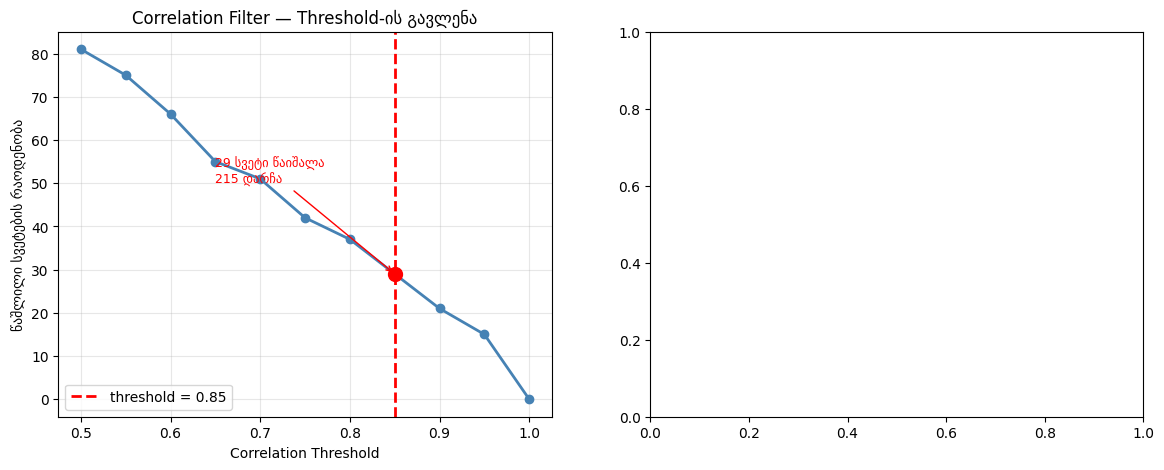

In [63]:

pre_pipeline = Pipeline([
    ("nan_imputer",     HouseHandleNaN()),
    ("ordinal_encoder", OrdinalEncoder()),
    ("feature_adder",   HouseFeatureAdderAndModifier()),
    ("preprocessor",    preprocessor),
])

X_pre = pre_pipeline.fit_transform(X_train, y_train)
X_df  = pd.DataFrame(X_pre)

corr_matrix = X_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

thresholds     = np.arange(0.5, 1.01, 0.05)
dropped_counts = []

for thresh in thresholds:
    features_to_drop = set()
    for col in upper.columns:
        if any(upper[col] > thresh):
            partners = upper.index[upper[col] > thresh].tolist()
            for partner in partners:
                if corr_matrix[col].mean() >= corr_matrix[partner].mean():
                    features_to_drop.add(col)
                else:
                    features_to_drop.add(partner)
    dropped_counts.append(len(features_to_drop))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, dropped_counts, marker='o', color='steelblue', linewidth=2)
axes[0].axvline(x=0.85, color='red', linestyle='--', linewidth=2, label='threshold = 0.85')
axes[0].scatter([0.85], [29], color='red', zorder=5, s=100)
axes[0].annotate('29 სვეტი წაიშალა\n215 დარჩა',
                 xy=(0.85, 29), xytext=(0.65, 50), fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='red'), color='red')
axes[0].set_xlabel('Correlation Threshold')
axes[0].set_ylabel('წაშლილი სვეტების რაოდენობა')
axes[0].set_title('Correlation Filter — Threshold-ის გავლენა')
axes[0].legend()
axes[0].grid(True, alpha=0.3)



In [49]:
from sklearn.linear_model import Ridge
from sklearn.feature_selection import RFE

class RFESelector(BaseEstimator, TransformerMixin):
    def __init__(self, n_features_to_select=50, estimator=None):
        self.n_features_to_select = n_features_to_select
        self.estimator = estimator

    def fit(self, X, y):
        X = pd.DataFrame(X).reset_index(drop=True)
        self.feature_names_ = list(X.columns)
        est = self.estimator if self.estimator is not None else Ridge(alpha=10)
        self.rfe_ = RFE(estimator=est, n_features_to_select=self.n_features_to_select)
        self.rfe_.fit(X, y)
        self.selected_features_ = [
            f for f, s in zip(self.feature_names_, self.rfe_.support_) if s
        ]
        print(f"RFE selected: {len(self.selected_features_)} features")
        return self

    def transform(self, X):
        X = pd.DataFrame(X).reset_index(drop=True)
        X.columns = self.feature_names_
        return X[self.selected_features_].values

## Pipeline for linar model

In [50]:

full_pipeline_linear = Pipeline([
    ("nan_imputer", HouseHandleNaN()),
    ("ordinal_encoder",OrdinalEncoder()),
    ("feature_adder",HouseFeatureAdderAndModifier()),
    ("preprocessor",preprocessor),
    ("scaler", StandardScaler()),
    ("corr_filter", CorrelationFilter(threshold=0.85)),
    ("rfe", RFESelector(n_features_to_select=80)),
])

## Train and Log Linear Models

In [51]:
import skops.io as sio

# log pipeline
mlflow.set_experiment("preprocessing_pipeline")
with mlflow.start_run(run_name="preprocessing_pipeline_linear"):
    mlflow.log_param("corr_threshold", 0.85)
    mlflow.log_param("num_impute_strategy", "median")
    mlflow.log_param("cat_impute_strategy", "most_frequent")
    mlflow.log_param("ordinal_encoded_cols",str(ordinaly_encoded_cols))
    mlflow.log_param("rfe_n_features", 80)
    mlflow.log_param("rfe_estimator", "Ridge_alpha10")
    sio.dump(full_pipeline_linear, "preprocessing_pipeline_linear.skops")
    mlflow.log_artifact("preprocessing_pipeline_linear.skops")
    preprocessing_run_id = mlflow.active_run().info.run_id
    print(f"Preprocessing run id: {preprocessing_run_id}")



Preprocessing run id: 47d69149821f4b0e813e978155f0a9b8
🏃 View run preprocessing_pipeline_linear at: https://dagshub.com/ZukaCS/house-prices-ML-assignment1.mlflow/#/experiments/2/runs/47d69149821f4b0e813e978155f0a9b8
🧪 View experiment at: https://dagshub.com/ZukaCS/house-prices-ML-assignment1.mlflow/#/experiments/2


In [52]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate
import skops.io as sio

kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

X_train_linear = full_pipeline_linear.fit_transform(X_train, y_train_log)
X_test_linear  = full_pipeline_linear.transform(X_test)
print(f"Train shape: {X_train_linear.shape}")

models_rfe = [
    ("LinearRegression", LinearRegression()),
    ("Ridge_1", Ridge(alpha=1)),
    ("Ridge_10",Ridge(alpha=10)),
    ("Ridge_50", Ridge(alpha=50)),
    ("Ridge_100", Ridge(alpha=100)),
    ("Ridge_500", Ridge(alpha=500)),
    ("Ridge_1000",Ridge(alpha=1000)),
    ("Ridge_5000",Ridge(alpha=5000)),
    ("Ridge_10000",Ridge(alpha=10000)),
    ("Lasso_0001", Lasso(alpha=0.001,  max_iter=10000)),
    ("Lasso_0005", Lasso(alpha=0.0005, max_iter=10000)),
    ("Lasso_0002", Lasso(alpha=0.002,  max_iter=10000)),
    ("Lasso_001", Lasso(alpha=0.01, max_iter=10000)),
    ("Lasso_005", Lasso(alpha=0.005, max_iter=10000)),
    ("Lasso_01", Lasso(alpha=0.1, max_iter=10000)),
    ("Lasso_1", Lasso(alpha=1.0,max_iter=10000)),
]

mlflow.set_experiment("linear_regression_v2")

for name, model in models_rfe:
    with mlflow.start_run(run_name=name):
        mlflow.set_tag("preprocessing_run_id", preprocessing_run_id)
        mlflow.set_tag("model_type",           type(model).__name__)

        cv_results = cross_validate(
            model, X_train_linear, y_train_log,
            cv=kf,
            scoring=["r2", "neg_root_mean_squared_error"],
            return_train_score=True
        )
        train_r2      = cv_results["train_r2"].mean()
        val_r2        = cv_results["test_r2"].mean()
        val_log_rmse  = -cv_results["test_neg_root_mean_squared_error"].mean()

        model.fit(X_train_linear, y_train_log)
        test_preds  = np.expm1(model.predict(X_test_linear))
        train_preds = np.expm1(model.predict(X_train_linear))

        test_r2           = r2_score(y_test, test_preds)
        test_rmse         = np.sqrt(mean_squared_error(y_test,  test_preds))
        train_rmse        = np.sqrt(mean_squared_error(y_train, train_preds))
        test_rmsle_score  = rmsle(y_test,  test_preds)
        train_rmsle_score = rmsle(y_train, train_preds)

        mlflow.log_params(model.get_params())
        mlflow.log_metric("train_r2", train_r2)
        mlflow.log_metric("val_r2",  val_r2)
        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("train_rmsle", train_rmsle_score)
        mlflow.log_metric("test_rmse", test_rmse)
        mlflow.log_metric("test_r2",  test_r2)
        mlflow.log_metric("test_rmsle", test_rmsle_score)

        sio.dump(model, "model.skops")
        mlflow.log_artifact("model.skops")

Dropped 29 correlated features
Remaining: 215 features
RFE selected: 80 features
Train shape: (1168, 80)
🏃 View run LinearRegression at: https://dagshub.com/ZukaCS/house-prices-ML-assignment1.mlflow/#/experiments/5/runs/92b6e22bc7c14af39e389fe8cba142ac
🧪 View experiment at: https://dagshub.com/ZukaCS/house-prices-ML-assignment1.mlflow/#/experiments/5


KeyboardInterrupt: 

# Pipeline for DT regression

In [ ]:

dt_pipeline = Pipeline([
    ("nan_imputer",  HouseHandleNaN()),
    ("ordinal_encoder", OrdinalEncoder()),
    ("feature_adder", HouseFeatureAdderAndModifier()),
    ("preprocessor", preprocessor)
])

In [ ]:
mlflow.set_experiment("preprocessing_pipeline")
with mlflow.start_run(run_name="preprocessing_pipeline_decision_tree"):
    mlflow.log_param("corr_threshold",       "none")
    mlflow.log_param("num_impute_strategy",  "median")
    mlflow.log_param("cat_impute_strategy",  "most_frequent")
    mlflow.log_param("ordinal_encoded_cols", str(ordinaly_encoded_cols))
    mlflow.log_param("rfe", "none")
    mlflow.log_param("scaler", "none")
    sio.dump(dt_pipeline, "preprocessing_pipeline_dt.skops")
    mlflow.log_artifact("preprocessing_pipeline_dt.skops")
    dt_preprocessing_run_id = mlflow.active_run().info.run_id
    print(f"DT Preprocessing run id: {dt_preprocessing_run_id}")

# Train and Log DT regression

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
import pandas as pd
import skops.io as sio

X_train_dt = dt_pipeline.fit_transform(X_train, y_train)
X_test_dt  = dt_pipeline.transform(X_test)
print(f"Train shape: {X_train_dt.shape}")

param_grid = {
    'criterion': ["squared_error"],
    'max_depth': [2, 3, 5, 10, 15, 20, None],
    'min_samples_leaf': [2, 5, 8, 10, 15]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=kf,
    scoring=["r2", "neg_root_mean_squared_error"],
    refit="neg_root_mean_squared_error",
    return_train_score=True,
    n_jobs=-1
)

print("Running GridSearchCV...")
grid_search.fit(X_train_dt, y_train)

results_df = pd.DataFrame(grid_search.cv_results_)

results_df = results_df.sort_values(by="rank_test_neg_root_mean_squared_error", ascending=True)

mlflow.set_experiment("decision_tree_regression_v1")

def evaluate_and_log(row, tag):
    params = row["params"]
    name = f"DT_depth{params['max_depth']}_leaf{params['min_samples_leaf']}"
    
    model = DecisionTreeRegressor(**params, random_state=42)
    model.fit(X_train_dt, y_train)
    
    train_preds = model.predict(X_train_dt)
    test_preds  = model.predict(X_test_dt)
    
    train_rmse       = np.sqrt(mean_squared_error(y_train, train_preds)) 
    test_r2          = r2_score(y_test, test_preds)
    test_rmse        = np.sqrt(mean_squared_error(y_test, test_preds))
    test_rmsle_score = rmsle(y_test, test_preds)
    train_rmsle_score = rmsle(y_train, train_preds) 
    
    with mlflow.start_run(run_name=f"{tag}_{name}"):
        mlflow.set_tag("preprocessing_run_id", dt_preprocessing_run_id)
        mlflow.set_tag("model_type", "DecisionTree")
        mlflow.set_tag("rank", tag)

        mlflow.log_params(params)
        mlflow.log_metric("train_r2",    row["mean_train_r2"])
        mlflow.log_metric("val_r2",      row["mean_test_r2"])
        mlflow.log_metric("train_rmse",  train_rmse)  
        mlflow.log_metric("train_rmsle", train_rmsle_score)  
        mlflow.log_metric("test_rmse",   test_rmse)
        mlflow.log_metric("test_r2",     test_r2)
        mlflow.log_metric("test_rmsle",  test_rmsle_score)

        sio.dump(model, "model.skops")
        mlflow.log_artifact("model.skops")

        print(f"Logged {tag}: {name} | val_rmse={-row['mean_test_neg_root_mean_squared_error']:.0f} | test_rmsle={test_rmsle_score:.4f}")

print("Log top 5 best")
for _, row in results_df.head(5).iterrows():
    evaluate_and_log(row, "best")

print("log to 5 worst")
for _, row in results_df.tail(5).iterrows():
    evaluate_and_log(row, "worst")

# DT pipeline with filters

In [ ]:
dt_pipeline_CF_RFE = Pipeline([
    ("nan_imputer",  HouseHandleNaN()),
    ("ordinal_encoder", OrdinalEncoder()),
    ("feature_adder", HouseFeatureAdderAndModifier()),
    ("preprocessor",  preprocessor),
    ("corr_filter", CorrelationFilter(threshold=0.85)),
    ("rfe", RFESelector(n_features_to_select=80)),
])


In [ ]:
mlflow.set_experiment("preprocessing_pipeline")
with mlflow.start_run(run_name="preprocessing_pipeline_dt_CF_RFE"):
    mlflow.log_param("num_impute_strategy",  "median")
    mlflow.log_param("cat_impute_strategy",  "most_frequent")
    mlflow.log_param("ordinal_encoded_cols", str(ordinaly_encoded_cols))
    mlflow.log_param("corr_threshold",  0.85)
    mlflow.log_param("rfe_n_features", 80)
    mlflow.log_param("rfe_estimator",  "Ridge_alpha10")
    mlflow.log_param("scaler",   "none")
    sio.dump(dt_pipeline_CF_RFE, "preprocessing_pipeline_dt_CF_RFE.skops")
    mlflow.log_artifact("preprocessing_pipeline_dt_CF_RFE.skops")
    dt_cf_rfe_preprocessing_run_id = mlflow.active_run().info.run_id
    print(f"DT CF RFE Preprocessing run id: {dt_cf_rfe_preprocessing_run_id}")

# Train DT with Correlation and Recursive filters

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
import pandas as pd
import skops.io as sio

X_train_dt = dt_pipeline_CF_RFE.fit_transform(X_train, y_train)
X_test_dt  = dt_pipeline_CF_RFE.transform(X_test)
print(f"Train shape: {X_train_dt.shape}")

param_grid = {
    'criterion': ["squared_error"],
    'max_depth': [2, 3, 5, 10, 15, 20, None],
    'min_samples_leaf': [2, 5, 8, 10, 15]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=kf,
    scoring=["r2", "neg_root_mean_squared_error"],
    refit="neg_root_mean_squared_error",
    return_train_score=True,
    n_jobs=-1
)

print("Running GridSearchCV...")
grid_search.fit(X_train_dt, y_train)

results_df = pd.DataFrame(grid_search.cv_results_)

results_df = results_df.sort_values(by="rank_test_neg_root_mean_squared_error", ascending=True)

mlflow.set_experiment("decision_tree_regression_CF_AND_RFE")

def evaluate_and_log(row, tag):
    params = row["params"]
    name = f"DT_CF_AND_RFE_depth{params['max_depth']}_leaf{params['min_samples_leaf']}"
    
    model = DecisionTreeRegressor(**params, random_state=42)
    model.fit(X_train_dt, y_train)
    
    train_preds = model.predict(X_train_dt)
    test_preds  = model.predict(X_test_dt)
    
    train_rmse       = np.sqrt(mean_squared_error(y_train, train_preds)) 
    test_r2          = r2_score(y_test, test_preds)
    test_rmse        = np.sqrt(mean_squared_error(y_test, test_preds))
    test_rmsle_score = rmsle(y_test, test_preds)
    train_rmsle_score = rmsle(y_train, train_preds) 
    
    with mlflow.start_run(run_name=f"{tag}_{name}"):
        mlflow.set_tag("preprocessing_run_id", dt_cf_rfe_preprocessing_run_id)
        mlflow.set_tag("model_type", "DecisionTree")
        mlflow.set_tag("rank", tag)

        mlflow.log_params(params)
        mlflow.log_metric("train_r2", row["mean_train_r2"])
        mlflow.log_metric("val_r2",  row["mean_test_r2"])
        mlflow.log_metric("train_rmse", train_rmse)  
        mlflow.log_metric("train_rmsle",train_rmsle_score)  
        mlflow.log_metric("test_rmse", test_rmse)
        mlflow.log_metric("test_r2", test_r2)
        mlflow.log_metric("test_rmsle", test_rmsle_score)

        sio.dump(model, "model.skops")
        mlflow.log_artifact("model.skops")

        print(f"Logged {tag}: {name} | val_rmse={-row['mean_test_neg_root_mean_squared_error']:.0f} | test_rmsle={test_rmsle_score:.4f}")

print("Log top 5 best")
for _, row in results_df.head(5).iterrows():
    evaluate_and_log(row, "best")

print("log to 5 worst")
for _, row in results_df.tail(5).iterrows():
    evaluate_and_log(row, "worst")

# RF pipeline

In [ ]:
rf_pipeline = Pipeline([
    ("nan_imputer",     HouseHandleNaN()),
    ("ordinal_encoder", OrdinalEncoder()),
    ("feature_adder",   HouseFeatureAdderAndModifier()),
    ("preprocessor",    preprocessor)
])
mlflow.set_experiment("preprocessing_pipeline")
with mlflow.start_run(run_name="preprocessing_pipeline_random_forest"):
    mlflow.log_param("num_impute_strategy",  "median")
    mlflow.log_param("cat_impute_strategy",  "most_frequent")
    mlflow.log_param("ordinal_encoded_cols", str(ordinaly_encoded_cols))
    mlflow.log_param("corr_filter",   "none")
    mlflow.log_param("rfe",  "none")
    mlflow.log_param("scaler", "none")
    sio.dump(rf_pipeline, "preprocessing_pipeline_rf.skops")
    mlflow.log_artifact("preprocessing_pipeline_rf.skops")
    rf_preprocessing_run_id = mlflow.active_run().info.run_id
    print(f"RF Preprocessing run id: {rf_preprocessing_run_id}")

# RFE train and log

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import pandas as pd
import skops.io as sio
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

X_train_rf = rf_pipeline.fit_transform(X_train, y_train)
X_test_rf  = rf_pipeline.transform(X_test)
print(f"Train shape: {X_train_rf.shape}")

param_grid = {
    'n_estimators': [100, 200, 300],          
    'max_depth': [10, 15, 20, None],          
    'min_samples_leaf': [2, 4, 6],       
    'max_features': [0.3, 0.5, 0.7]   
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=kf,
    scoring=["r2", "neg_root_mean_squared_error"],
    refit="neg_root_mean_squared_error",
    return_train_score=True,
    n_jobs=-1
)

print("Running RandomForest GridSearchCV...")
grid_search.fit(X_train_rf, y_train)

results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values(by="rank_test_neg_root_mean_squared_error", ascending=True)

mlflow.set_experiment("random_forest_regression_v1")

def evaluate_and_log(row, tag):
    params = row["params"]
    name = f"RF_{params['n_estimators']}_depth{params['max_depth']}_leaf{params['min_samples_leaf']}_features{params['max_features']}"
    
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train_rf, y_train)
    
    train_preds = model.predict(X_train_rf)
    test_preds  = model.predict(X_test_rf)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    train_rmsle_score = rmsle(y_train, train_preds)
    
    test_r2 = r2_score(y_test, test_preds)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    test_rmsle_score = rmsle(y_test, test_preds)
    
    with mlflow.start_run(run_name=f"{tag}_{name}"):
        mlflow.set_tag("preprocessing_run_id", rf_preprocessing_run_id)
        mlflow.set_tag("model_type", "RandomForest")
        mlflow.set_tag("rank", tag)

        mlflow.log_params(params)
        mlflow.log_metric("train_r2", row["mean_train_r2"])
        mlflow.log_metric("val_r2",  row["mean_test_r2"])
        mlflow.log_metric("train_rmse", train_rmse)  
        mlflow.log_metric("train_rmsle",train_rmsle_score)  
        mlflow.log_metric("test_rmse", test_rmse)
        mlflow.log_metric("test_r2", test_r2)
        mlflow.log_metric("test_rmsle",  test_rmsle_score)

        sio.dump(model, "model.skops")
        mlflow.log_artifact("model.skops")

        print(f"Logged {tag}: {name} | val_rmse={-row['mean_test_neg_root_mean_squared_error']:.0f} | test_rmsle={test_rmsle_score:.4f}")

print("Log top 4 best")
for _, row in results_df.head(4).iterrows():
    evaluate_and_log(row, "best")

print("Log top 4 worst")
for _, row in results_df.tail(4).iterrows():
    evaluate_and_log(row, "worst")

## RF pipeline with filters

In [ ]:
rf_pipeline_CF_RFE = Pipeline([
    ("nan_imputer",     HouseHandleNaN()),
    ("ordinal_encoder", OrdinalEncoder()),
    ("feature_adder",   HouseFeatureAdderAndModifier()),
    ("preprocessor",    preprocessor),
    ("corr_filter",     CorrelationFilter(threshold=0.85)),
    ("rfe",             RFESelector(n_features_to_select=80)),
])

mlflow.set_experiment("preprocessing_pipeline")
with mlflow.start_run(run_name="preprocessing_pipeline_random_forest_CF_RFE"):
    mlflow.log_param("num_impute_strategy",  "median")
    mlflow.log_param("cat_impute_strategy",  "most_frequent")
    mlflow.log_param("ordinal_encoded_cols", str(ordinaly_encoded_cols))
    mlflow.log_param("corr_filter",   0.85)
    mlflow.log_param("rfe_n_features", 80)
    mlflow.log_param("rfe_estimator",  "Ridge_alpha10")
    mlflow.log_param("scaler",  "none")
    sio.dump(rf_pipeline_CF_RFE, "preprocessing_pipeline_rf_CF_RFE.skops")
    mlflow.log_artifact("preprocessing_pipeline_rf_CF_RFE.skops")
    rf_cf_rfe_preprocessing_run_id = mlflow.active_run().info.run_id
    print(f"RF CF RFE Preprocessing run id: {rf_cf_rfe_preprocessing_run_id}")

## Train RF with filters and log them

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

X_train_rf_cf_rfe = rf_pipeline_CF_RFE.fit_transform(X_train, y_train)
X_test_rf_cf_rfe  = rf_pipeline_CF_RFE.transform(X_test)
print(f"Train shape: {X_train_rf_cf_rfe.shape}")

param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [10, 15, 20, None],
    'min_samples_leaf': [2, 4, 6],
    'max_features':     [0.3, 0.5, 0.7],
}

print("Running RandomForest GridSearchCV...")
grid_search_rf = GridSearchCV(
    estimator  = RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid = param_grid,
    cv         = kf,
    scoring    = ["r2", "neg_root_mean_squared_error"],
    refit      = "neg_root_mean_squared_error",
    return_train_score = True,
    n_jobs     = 1,
)

grid_search_rf.fit(X_train_rf_cf_rfe, y_train)

results_rf = pd.DataFrame(grid_search_rf.cv_results_)
results_rf = results_rf.sort_values(by="rank_test_neg_root_mean_squared_error", ascending=True)

mlflow.set_experiment("random_forest_CF_RFE")

def evaluate_and_log_rf(row, tag):
    params = row["params"]
    name = f"RF_n{params['n_estimators']}_depth{params['max_depth']}_leaf{params['min_samples_leaf']}_feat{params['max_features']}"

    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train_rf_cf_rfe, y_train)

    train_preds = model.predict(X_train_rf_cf_rfe)
    test_preds  = model.predict(X_test_rf_cf_rfe)

    train_rmse        = np.sqrt(mean_squared_error(y_train, train_preds))
    test_r2           = r2_score(y_test, test_preds)
    test_rmse         = np.sqrt(mean_squared_error(y_test, test_preds))
    test_rmsle_score  = rmsle(y_test, test_preds)
    train_rmsle_score = rmsle(y_train, train_preds)

    with mlflow.start_run(run_name=f"{tag}_{name}"):
        mlflow.set_tag("preprocessing_run_id", rf_cf_rfe_preprocessing_run_id)
        mlflow.set_tag("model_type",           "RandomForest")
        mlflow.set_tag("rank",                 tag)

        mlflow.log_params(params)
        mlflow.log_metric("train_r2",    row["mean_train_r2"])
        mlflow.log_metric("val_r2",      row["mean_test_r2"])
        mlflow.log_metric("train_rmse",  train_rmse)
        mlflow.log_metric("train_rmsle", train_rmsle_score)
        mlflow.log_metric("test_rmse",   test_rmse)
        mlflow.log_metric("test_r2",     test_r2)
        mlflow.log_metric("test_rmsle",  test_rmsle_score)

        sio.dump(model, "model.skops")
        mlflow.log_artifact("model.skops")

        print(f"Logged {tag}: {name} | val_rmse={-row['mean_test_neg_root_mean_squared_error']:.0f} | test_rmsle={test_rmsle_score:.4f}")

print("Log top 4 best")
for _, row in results_rf.head(4).iterrows():
    evaluate_and_log_rf(row, "best")

print("Log top 4 worst")
for _, row in results_rf.tail(4).iterrows():
    evaluate_and_log_rf(row, "worst")

## Register best model

In [ ]:
client = mlflow.tracking.MlflowClient()

runs = client.search_runs(
    experiment_ids=[client.get_experiment_by_name("linear_regression_v2").experiment_id],
    order_by=["metrics.test_rmsle ASC"],
    max_results=1
)

best_run_id = runs[0].info.run_id
print(f"Best run: {runs[0].info.run_name} | {best_run_id}")

artifacts = client.list_artifacts(best_run_id)
for a in artifacts:
    print(a.path)

In [ ]:
client = mlflow.tracking.MlflowClient()

runs = client.search_runs(
    experiment_ids=[client.get_experiment_by_name("linear_regression_v2").experiment_id],
    filter_string="tags.model_type = 'Lasso'",
    order_by=["metrics.test_rmsle ASC"],
    max_results=1
)

best_run_id = runs[0].info.run_id
print(f"Best run: {runs[0].info.run_name} | {best_run_id}")

artifacts = client.list_artifacts(best_run_id)
for a in artifacts:
    print(a.path)

In [ ]:
pipeline_runs = client.search_runs(
    experiment_ids=[client.get_experiment_by_name("preprocessing_pipeline").experiment_id],
    filter_string="tags.mlflow.runName = 'preprocessing_pipeline_linear'",
    max_results=1
)
pipeline_run_id = pipeline_runs[0].info.run_id
print(f"Pipeline run: {pipeline_run_id}")

artifacts = client.list_artifacts(pipeline_run_id)
for a in artifacts:
    print(a.path)

In [ ]:
client.create_registered_model("HousePrice_Lasso_best")

version = client.create_model_version(
    name="HousePrice_Lasso_best",
    source=f"runs:/{best_run_id}/model.skops",
    run_id=best_run_id
)

print("Version:", version.version)
print("Status:", version.status)